In [1]:
import sympy as sym
from sympy.printing.dot import dotprint
import graphviz

In [2]:
def sympy_expr_to_graph(expr,fillcolor='lightblue'):
    """
    Convert a SymPy expression into a Graphviz Digraph for visualization.
    """
    #dot = graphviz.Digraph(comment="SymPy Expression Tree")
    dot = graphviz.Digraph(
        comment="SymPy Expression Tree",
        graph_attr={'bgcolor': 'transparent'},
        node_attr={'style': 'filled', 'fillcolor': fillcolor},
    )    
    visited = {}

    def add_node(e):
        # Use id(e) to uniquely identify nodes
        node_id = str(id(e))
        if node_id not in visited:
            visited[node_id] = True
            # Label: operator or symbol/number
            etype = type(e)
            etype_name = str(etype).split('.')[-1].split("'")[0]  #strip off only the fundamental not the whole class hierarchy
            label = str(e)
            new_label = etype_name+'\n'+label
            #print(new_label)
            dot.node(node_id, new_label)

            # Recursively add children
            if hasattr(e, 'args'):
                for arg in e.args:
                    child_id = add_node(arg)
                    dot.edge(node_id, child_id)
        return node_id

    add_node(expr)
    return dot


def graph_expr(expr,color='white'):
    styles = [(Basic, {'style': 'filled',
                       'fillcolor': color,
                       'shape': 'ellipse'})]
    dot_form = dotprint(expr, styles=styles)
    return graphviz.Source(dot_form)

def export_expression(expr,dpi_num,filename_no_suffix,file_format,fillcolor='White'):
    temp = setg(expr,fillcolor=fillcolor)
    temp.attr(dpi=str(dpi_num))
    temp.render(filename_no_suffix,format='png', cleanup=True)

def report_attrs(expr):
    print("Making a list of attrs for %s"%expr.func)
    return [x for x in dir(expr) if not x.startswith("_")]

setg = sympy_expr_to_graph

In [3]:
a, b, x, y, z = sym.symbols('a b x y z')
w, q = sym.symbols('omega phi')
p = sym.Wild('p')

In [4]:
f = sym.Function('f')
g = sym.Function('g')
h = sym.Function('h')
F = sym.Function('F')
G = sym.Function('G')
H = sym.Function('H')

In [5]:
is_deriv = lambda e: isinstance(e, sym.Derivative)
val      = lambda e: sym.Mul(e.expr, *[sym.I*v for v,n in e.variable_count for _ in range(n)])

In [6]:
def Fderiv_subs(expr,pairs):
    temp1 = expr.replace(is_deriv,val)
    return temp1.subs(pairs)

Derivative(f(x), x)

I*x*f(x)

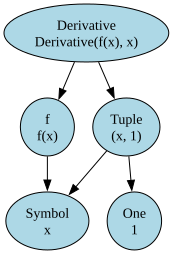

In [7]:
simp1 = sym.diff(f(x),x)
display(simp1, val(simp1))
setg(simp1)
#export_expression(simp1,300,'A2D_07(Jul)_2026_Derivative_rewriting_simple','png',fillcolor='#ff6666')

Derivative(h(x, y), x, (y, 2))

-I*x*y**2*h(x, y)

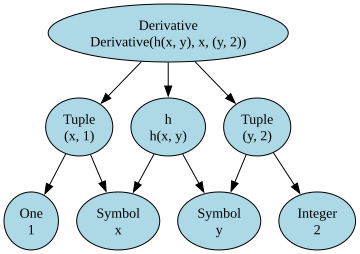

In [8]:
simp2 = sym.diff(h(x,y),x,(y,2))
display(simp2,val(simp2))
setg(simp2)
#export_expression(simp2,300,'A2D_07(Jul)_2026_Derivative_rewriting_medium','png',fillcolor='#ff6666')

Derivative(h(x, y, z), (x, 2), (y, 2))

x**2*y**2*h(x, y, z)

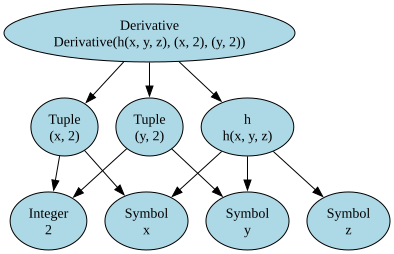

In [9]:
simp3 = sym.diff(h(x,y,z),(x,2),(y,2))
display(simp3,val(simp3))
setg(simp3)
#export_expression(simp2,300,'A2D_07(Jul)_2026_Derivative_rewriting_medium','png',fillcolor='#ff6666')

In [12]:
target = simp1
display(Fderiv_subs(target,{x:w,y:q,f:F,g:G,h:H}))

I*omega*F(omega)

In [13]:
target = simp2
display(Fderiv_subs(target,{x:w,y:q,f:F,g:G,h:H}))

-I*omega*phi**2*H(omega, phi)

In [14]:
target = simp3
display(Fderiv_subs(target,{x:w,y:q,f:F,g:G,h:H}))

omega**2*phi**2*H(omega, phi, z)

In [15]:
# Derivatives buried inside a larger expression
expr1 = sym.sin(sym.diff(g(x), x)) + h(x)*sym.diff(g(x), x) + 1 + sym.exp(sym.diff(f(x,y,z),(y,2)))
display(expr1,expr1.replace(is_deriv,val))
display(Fderiv_subs(expr1,{x:w,y:q,f:F,g:G,h:H}))

h(x)*Derivative(g(x), x) + exp(Derivative(f(x, y, z), (y, 2))) + sin(Derivative(g(x), x)) + 1

I*x*g(x)*h(x) + I*sinh(x*g(x)) + 1 + exp(-y**2*f(x, y, z))

I*omega*G(omega)*H(omega) + I*sinh(omega*G(omega)) + 1 + exp(-phi**2*F(omega, phi, z))